
---
date: "2026-09-08"
date-modified: last-modified
format:
  html:
    toc: true
---



# Decision Trees for Regression and Classification

Tree-based methods represent a family of non-parametric supervised learning algorithms applicable to both [regression](linear-regression.ipynb) and [classification](classification.ipynb) problems. Unlike classical linear models that fit a single global equation across the entire predictor space, tree methods segment the predictor space into a set of disjoint, simple rectangular regions. To make a prediction for an input observation, the algorithm simply assigns the mean (for regression) or the majority mode (for classification) of the training observations in the region to which it belongs.

While individual decision trees are simple and offer direct interpretability, they are typically not competitive with top supervised learning models in raw predictive accuracy due to high variance. However, they serve as the foundational "weak learners" for state-of-the-art ensemble architectures—including [Bagging](bagging-and-random-forests.ipynb), [Random Forests](bagging-and-random-forests.ipynb), and [Boosting](boosting.ipynb).

---

## 1\. Foundations of Decision Trees & Comparison with Linear Models

A decision tree structures the decision-making process into an inverted hierarchical tree composed of a **root node**, **internal nodes** (splits), **branches**, and **terminal nodes** (leaves). 

::: {.callout-note}
## Intuition: Decision Trees Mirror Human Decision Processes
In operational research and practical management, human decisions are naturally structured sequentially: check *Condition 1*; if satisfied, branch left and check *Condition 2*; otherwise, branch right. Decisions proceed along connected branches until a final deterministic outcome is reached. Decision trees formalize this intuitive procedural logic into an axis-aligned spatial partition.
:::

### 1.1\. Motivating Example: Baseball Player Salary Prediction

Consider the classical **Hitters** dataset analyzed in the lecture, where the objective is to predict a baseball player's $\text{Salary}$ (log-transformed to stabilize right-skewness) based on two predictors:

1. $\text{Years}$: The number of years played in the major leagues (career experience).
2. $\text{Hits}$: The number of hits made in the previous season (recent performance).

A fitted regression tree stratifies the 2D feature space into three distinct rectangular regions:

* **Region 1 ($R_1$):** $\{\mathbf{X} \mid \text{Years} < 4.5\}$. For players with under 5 years of experience, the predicted log salary is $5.11$ (translating to $e^{5.11} \approx \$165{,}174$). For junior players, the number of hits in the previous year has virtually no impact on compensation.
* **Region 2 ($R_2$):** $\{\mathbf{X} \mid \text{Years} \ge 4.5, \, \text{Hits} < 117.5\}$. For veteran players with fewer than $118$ hits, the predicted log salary is $6.00$ ($e^{6.00} \approx \$402{,}834$).
* **Region 3 ($R_3$):** $\{\mathbf{X} \mid \text{Years} \ge 4.5, \, \text{Hits} \ge 117.5\}$. For veteran players with at least $118$ hits, the predicted log salary is $6.74$ ($e^{6.74} \approx \$845{,}346$).

::: {#def-regression-tree-model}
## Regression Tree Prediction Model
Let $\mathcal{X} \subset \mathbb{R}^p$ denote the predictor space. A regression tree segments $\mathcal{X}$ into $J$ disjoint, non-overlapping regions $R_1, R_2, \dots, R_J$. The model predicts a constant response $c_j$ within each region $R_j$:

$$
f(\mathbf{X}) = \sum_{j=1}^J c_j \cdot \mathbf{1}_{\{\mathbf{X} \in R_j\}}
$$

Under a squared error loss criterion, the optimal constant $c_j$ for region $R_j$ is the sample mean of the training observations falling in $R_j$:

$$
\hat{y}_{R_j} = \frac{1}{|R_j|} \sum_{i: \mathbf{x}_i \in R_j} y_i
$$
:::

### 1.2\. Trees Versus Linear Models

The fundamental structural difference between linear models and tree-based models lies in their functional representation of the target surface:

* **Linear Regression:** Assumes a global parametric hyperplane:
  $$
  f(\mathbf{X}) = \beta_0 + \sum_{j=1}^p \beta_j X_j
  $$
* **Regression Tree:** Assumes a local non-parametric piecewise constant step function over axis-parallel boxes:
  $$
  f(\mathbf{X}) = \sum_{j=1}^J \hat{y}_{R_j} \cdot \mathbf{1}_{\{\mathbf{X} \in R_j\}}
  $$

::: {.callout-note}
## Intuition: Geometry of Decision Boundaries
If the true relationship between the predictors and the response is well approximated by a smooth linear function, classical linear regression will dominate because a tree must approximate a diagonal boundary via an inefficient staircase of horizontal and vertical splits. 

Conversely, if the true relationship involves complex non-linearities and high-order interaction effects (e.g., if feature $X_2$ matters only when feature $X_1 > s$), a decision tree naturally captures this modular interaction, whereas standard linear regression without interaction terms fails completely.
:::



## 2\. Regression Trees & Recursive Binary Splitting

Let $\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^n$ denote a training dataset where each observation $\mathbf{x}_i = (x_{i1}, x_{i2}, \dots, x_{ip})^T \in \mathbb{R}^p$ represents $p$ predictor features and $y_i \in \mathbb{R}$ is a quantitative continuous response.

The goal is to find $J$ high-dimensional rectangular regions $R_1, R_2, \dots, R_J$ that minimize the **Residual Sum of Squares (RSS)**:

$$
\text{RSS} = \sum_{j=1}^J \sum_{i \in R_j} (y_i - \hat{y}_{R_j})^2
$$

where $\hat{y}_{R_j}$ is the mean response of the training observations within $R_j$.

::: {.callout-warning}
## Computational Complexity of Exhaustive Partitioning
It is computationally infeasible to evaluate every possible partition of $\mathbb{R}^p$ into $J$ arbitrary bounding boxes. The combinatorial search space over all subsets and coordinates is NP-hard. We must therefore adopt an efficient heuristic strategy.
:::

::: {#def-recursive-binary-splitting}
## Top-Down Greedy Recursive Binary Splitting
The standard algorithm for constructing a decision tree operates via **recursive binary splitting**:

1. **Top-Down:** The process begins at the root node, where all $n$ training observations belong to a single undivided region.
2. **Greedy:** At each step, the algorithm selects the single best split that achieves the greatest immediate reduction in RSS at that particular step, with no look-ahead to future splits.
3. **Binary:** Every split divides a parent region into exactly two child regions (half-planes).

To execute a split, the algorithm selects a predictor variable $X_j$ ($j \in \{1, \dots, p\}$) and a cutpoint $s \in \mathbb{R}$ that partition the current region into two half-planes:

$$
R_1(j, s) = \{\mathbf{X} \mid X_j < s\} \quad \text{and} \quad R_2(j, s) = \{\mathbf{X} \mid X_j \ge s\}
$$

The optimal pair $(j^*, s^*)$ is chosen to minimize the joint RSS of the two child regions:

$$
(j^*, s^*) = \arg\min_{j, s} \left[ \sum_{i: \mathbf{x}_i \in R_1(j, s)} (y_i - \hat{y}_{R_1})^2 + \sum_{i: \mathbf{x}_i \in R_2(j, s)} (y_i - \hat{y}_{R_2})^2 \right]
$$
:::

::: {.callout-note}
## Intuition: Why Only Binary Splits?
Restricting splits to binary divisions is not a limitation. Any multi-way split (e.g., partitioning a variable into three ranges $X_j < s_1$, $s_1 \le X_j < s_2$, and $X_j \ge s_2$) can be implemented exactly via two consecutive binary splits. Restricting each step to a binary decision maintains computational efficiency and yields a well-behaved binary search tree.
:::

Once the initial split is performed, the feature space is divided into two regions. The algorithm then repeats this exact optimization process on one of the resulting regions to create three regions, and continues recursively.

### 2.1\. Stopping Criteria

The recursive splitting process continues until a stopping criterion is reached. Standard stopping criteria include:

1. **Minimum leaf size:** Splitting ceases when every terminal node contains fewer than a preset threshold of observations (e.g., $n_{\text{min}} = 5$).
2. **Maximum tree depth:** The tree terminates once a predefined maximum depth $d_{\text{max}}$ is attained.
3. **Maximum leaf count:** Tree growth stops when the total number of terminal leaves reaches a fixed limit.



## 3\. Overfitting & Cost Complexity Pruning

Growing a decision tree to completion until each terminal leaf contains only a few observations (or a single observation) produces an extremely flexible model.

::: {.callout-warning}
## The Overfitting Trap of Deep Trees
If a tree is grown until each terminal node holds exactly one observation, the predicted value $\hat{y}_{R_j}$ equals the exact response $y_i$ of that single training observation. The training error falls to zero:

$$
\text{RSS}_{\text{train}} = 0
$$

This creates extreme **overfitting**: the tree has merely memorized the sample noise. When evaluated on out-of-sample test data, its variance is massive, yielding poor test set generalization.
:::

### 3.1\. Why RSS Thresholding During Tree Growth Fails

A naive attempt to prevent overfitting is to halt splitting early whenever the reduction in RSS achieved by a split falls below a fixed threshold. 

*This strategy fails because it is too short-sighted:* A split early in the tree may yield an apparently negligible reduction in RSS, yet it may position the partitions such that a subsequent downstream split produces a massive reduction in RSS. Early stopping would overlook this valuable structure.

### 3.2\. Cost Complexity Pruning (Weakest Link Pruning)

The superior strategy is to first grow a very large, deep tree $T_0$ using stopping criteria based purely on node size, and then **prune** it back to obtain an optimal subtree.

::: {#def-cost-complexity-pruning}
## Cost Complexity Pruning Objective
Rather than evaluating all possible subtrees (which is computationally intractable), **cost complexity pruning** indexes a nested sequence of subtrees by a non-negative tuning parameter $\alpha \ge 0$.

For each value of $\alpha$, there corresponds a subtree $T \subseteq T_0$ that minimizes the penalized cost complexity objective:

$$
C_\alpha(T) = \sum_{m=1}^{|T|} \sum_{i: \mathbf{x}_i \in R_m} (y_i - \hat{y}_{R_m})^2 + \alpha |T|
$$

where:

* $|T|$ is the number of terminal nodes (leaves) in subtree $T$.
* $R_m$ is the rectangular region corresponding to the $m$-th terminal node.
* $\hat{y}_{R_m}$ is the predicted mean response in $R_m$.
* $\alpha \ge 0$ is a complexity tuning parameter that governs the bias-variance trade-off.
:::

::: {.callout-note}
## Intuition: Connection to Lasso Regularization
The penalty term $\alpha |T|$ plays exactly the same role as the $\ell_1$ penalty in [Lasso Regression](regularization.ipynb). When $\alpha = 0$, $C_0(T)$ simply measures training RSS, so the optimal subtree is the full unpruned tree $T_0$. As $\alpha$ increases, a penalty is paid for each additional leaf, forcing the optimal tree to shed branches in a strictly nested fashion until only the root node remains.
:::

::: {#thm-cost-complexity-cv}
## Subtree Optimization via $K$-Fold Cross-Validation
To determine the optimal complexity parameter $\alpha^*$:

1. Grow a large tree $T_0$ on the complete training dataset, stopping only when leaves contain fewer than $n_{\text{min}}$ observations.
2. Apply cost complexity pruning to $T_0$ to obtain a sequence of best subtrees as a function of $\alpha$.
3. Divide the training set into $K$ folds. For each $k \in \{1, \dots, K\}$:
   - Fit $T_0^{(-k)}$ and obtain the pruned subtree sequence on all data except fold $k$.
   - Evaluate the mean squared prediction error on the left-out $k$-th fold as a function of $\alpha$.
4. Average the cross-validation errors across all $K$ folds for each $\alpha$, and choose $\alpha^*$ that minimizes average error.
5. Return the subtree from Step 2 corresponding to the chosen $\alpha^*$.
:::



## 4\. Classification Trees & Node Purity Metrics

A **classification tree** predicts a qualitative discrete response $Y \in \{1, 2, \dots, K\}$. Rather than predicting the mean, the tree predicts that each test observation belongs to the **most commonly occurring class** (the mode) among the training observations in its region.

Let $\hat{p}_{mk}$ represent the proportion of training observations in region $m$ that belong to class $k$:

$$
\hat{p}_{mk} = \frac{1}{N_m} \sum_{i: \mathbf{x}_i \in R_m} \mathbf{1}_{\{y_i = k\}}, \quad N_m = \sum_{i=1}^n \mathbf{1}_{\{\mathbf{x}_i \in R_m\}}
$$

The predicted class $\hat{y}_{R_m}$ for region $R_m$ is determined by majority vote:

$$
\hat{y}_{R_m} = \arg\max_{k \in \{1, \dots, K\}} \hat{p}_{mk}
$$

### 4.1\. Why Classification Error Rate Fails as a Splitting Criterion

In regression, splits are evaluated by reduction in RSS. In classification, a natural candidate is the **classification error rate**:

$$
E_m = 1 - \max_{k} (\hat{p}_{mk})
$$

::: {.callout-warning}
## The Insensitivity of Error Rate to Node Purity
The classification error rate is not sufficiently sensitive to **node purity** to guide tree growth effectively.

Consider a two-class setting ($K = 2$) with $400$ observations in a parent node (200 in Class 1, 200 in Class 2, error $= 0.5$). Suppose we consider two potential splits:

* **Split A:** Creates Child 1 with $(100, 300)$ and Child 2 with $(100, 100)$. Both children have a majority class, giving an overall error of $100 + 100 = 200$ out of $400$ (error $= 0.5$). The classification error shows *zero* improvement.
* **Split B:** Creates Child 1 with $(0, 200)$ and Child 2 with $(200, 0)$. Both children are $100\%$ pure! 

Because the error rate metric does not reward producing pure nodes as aggressively as variance measures do, tree growing requires more sensitive purity criteria.
:::

### 4.2\. Purity Measures: Gini Index and Cross-Entropy

::: {#def-gini-index}
## Gini Index
The **Gini index** measures total class variance across the $K$ classes in region $m$:

$$
G_m = \sum_{k=1}^K \hat{p}_{mk} (1 - \hat{p}_{mk}) = 1 - \sum_{k=1}^K \hat{p}_{mk}^2
$$

The Gini index is a metric of **node purity**: it takes on a small value if all $\hat{p}_{mk}$ are close to zero or one. A value near zero indicates that the node contains predominantly observations from a single class.
:::

::: {#def-entropy}
## Cross-Entropy (Deviance)
An alternative to the Gini index is **cross-entropy** (or simply entropy):

$$
D_m = - \sum_{k=1}^K \hat{p}_{mk} \log \hat{p}_{mk}
$$

where by convention $0 \log 0 = 0$. Like the Gini index, entropy attains its minimum of zero when the node is entirely pure (i.e., $\hat{p}_{mk} = 1$ for some class $k$, and $0$ for all others).
:::

::: {.callout-note}
## Intuition: Mathematical Structure of Purity Functions
In a binary classification problem ($p = \hat{p}_{m1}$ and $1 - p = \hat{p}_{m2}$):

* The Gini term is $2p(1 - p)$.
* The Entropy term is $-p\log p - (1-p)\log(1-p)$.

Both functions are strictly concave, symmetric around $p = 0.5$, and vanish at $p = 0$ and $p = 1$. Minimizing $G_m$ or $D_m$ heavily penalizes mixed nodes and drives splits toward homogeneous subsets. In practice, Gini and Cross-Entropy produce very similar trees; either can be used for growing the tree, while classification error is preferred for final pruning validation.
:::



## 5\. Handling Categorical Predictors

Unlike standard linear models that require converting categorical features into sets of dummy binary variables ($n - 1$ variables for $n$ levels), decision trees handle qualitative predictors naturally.

For a categorical predictor $X_j$ with $L$ discrete levels $\{a_1, a_2, \dots, a_L\}$:

1. A split partitions the $L$ categories into two disjoint, non-empty subsets $S_1$ and $S_2$ such that $S_1 \cup S_2 = \{a_1, \dots, a_L\}$.
2. The left branch is defined by $\{X_j \in S_1\}$ and the right branch by $\{X_j \in S_2\}$.
3. The algorithm evaluates all $2^{L-1} - 1$ possible two-way partitions to find the subset pair that minimizes the split criterion (RSS for regression, Gini or Entropy for classification).

This avoids artificial distance metrics between qualitative categories and preserves the natural discrete groupings of the data.

---

## 6\. Geometric Visualization of Partitions & Node Purity Curves

Below, we visualize:
1. The contrast between a continuous linear decision boundary and an axis-aligned tree partition.
2. The comparative functional curves of the three classification criteria (Scaled Gini Index, Scaled Entropy, and Misclassification Error Rate) across probability $p \in [0, 1]$.


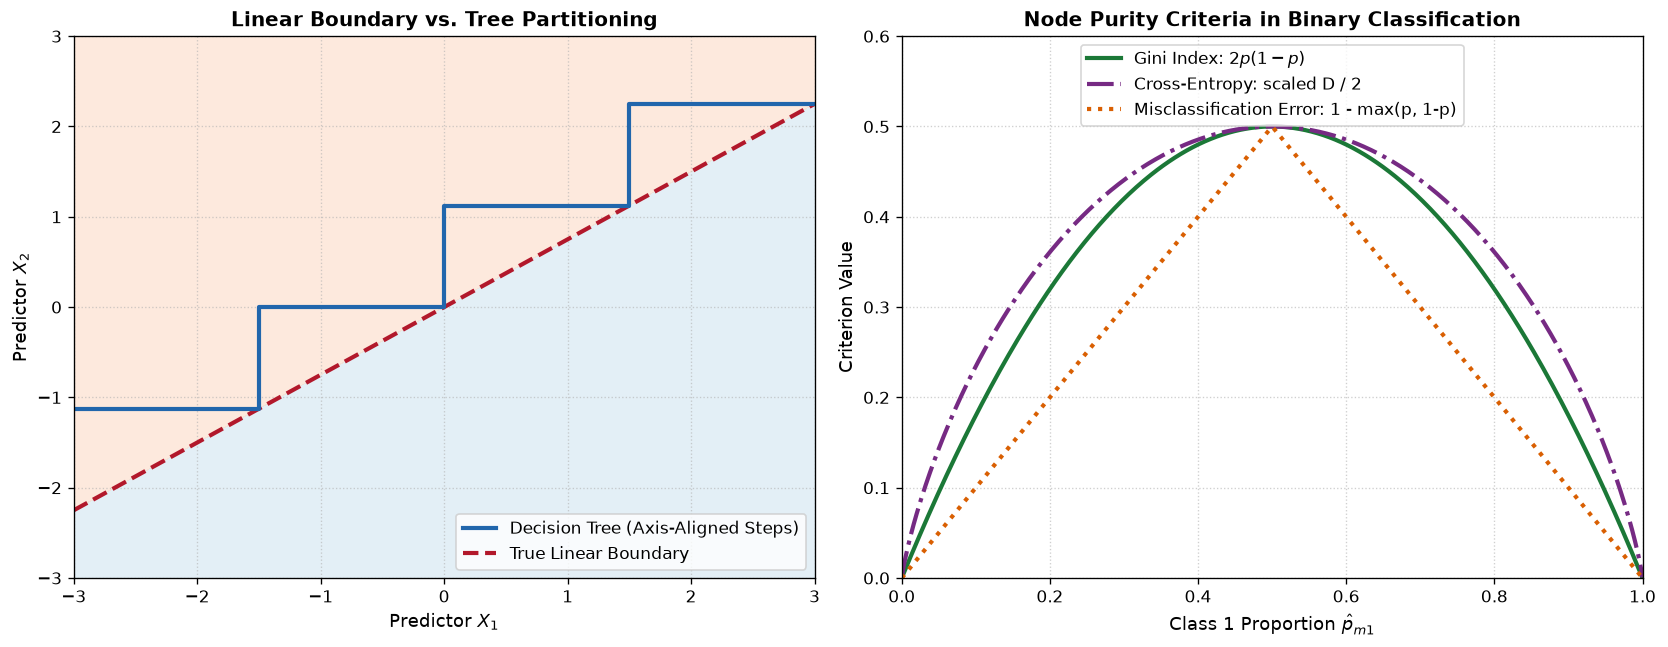

In [1]:

import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), dpi=120)

# -----------------------------------------------------
# Panel 1: Linear Boundary vs. Decision Tree Step Boundary
# -----------------------------------------------------
ax1 = axes[0]
x1 = np.linspace(-3, 3, 300)
x2 = np.linspace(-3, 3, 300)
X1, X2 = np.meshgrid(x1, x2)

# Linear decision boundary: X2 = 0.75 * X1
Z_linear = X2 - 0.75 * X1
ax1.contourf(X1, X2, Z_linear, levels=[-10, 0, 10], colors=['#d1e5f0', '#fddbc7'], alpha=0.6)
ax1.contour(X1, X2, Z_linear, levels=[0], colors=['#b2182b'], linewidths=2.5, linestyles='--')

# Decision tree approximation (axis-aligned steps)
tree_steps_x = [-3, -1.5, -1.5, 0.0, 0.0, 1.5, 1.5, 3]
tree_steps_y = [-1.125, -1.125, 0.0, 0.0, 1.125, 1.125, 2.25, 2.25]
ax1.step(tree_steps_x, tree_steps_y, where='post', color='#2166ac', linewidth=2.5, label='Decision Tree (Axis-Aligned Steps)')
ax1.plot([], [], '--', color='#b2182b', linewidth=2.5, label='True Linear Boundary')

ax1.set_title("Linear Boundary vs. Tree Partitioning", fontsize=12, fontweight='bold')
ax1.set_xlabel(r"Predictor $X_1$", fontsize=11)
ax1.set_ylabel(r"Predictor $X_2$", fontsize=11)
ax1.legend(frameon=True, facecolor='white', loc='lower right')
ax1.grid(True, linestyle=':', alpha=0.6)

# -----------------------------------------------------
# Panel 2: Purity Measures as a Function of Class Proportion
# -----------------------------------------------------
ax2 = axes[1]
p = np.linspace(0.0001, 0.9999, 500)

# Misclassification Error: E = 1 - max(p, 1-p)
error_rate = 1.0 - np.maximum(p, 1.0 - p)

# Gini Index: 2 * p * (1 - p). Scaled by 2 to compare with error rate peak of 0.5
gini = 2.0 * p * (1.0 - p)

# Entropy: -p*log2(p) - (1-p)*log2(1-p). Scaled by 0.5 so peak is 0.5
entropy = -0.5 * (p * np.log2(p) + (1.0 - p) * np.log2(1.0 - p))

ax2.plot(p, gini, label=r'Gini Index: $2p(1-p)$', color='#1b7837', linewidth=2.5)
ax2.plot(p, entropy, label='Cross-Entropy: scaled D / 2', color='#762a83', linewidth=2.5, linestyle='-.')
ax2.plot(p, error_rate, label='Misclassification Error: 1 - max(p, 1-p)', color='#d95f02', linewidth=2.5, linestyle=':')

ax2.set_title("Node Purity Criteria in Binary Classification", fontsize=12, fontweight='bold')
ax2.set_xlabel(r"Class 1 Proportion $\hat{p}_{m1}$", fontsize=11)
ax2.set_ylabel("Criterion Value", fontsize=11)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 0.6)
ax2.legend(frameon=True, facecolor='white', loc='upper center')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()
